# MalBERT-XAI: Dataset Preparation Pipeline
### Raw APK Folders → Training-Ready Multi-View CSV

**Pipeline Overview:**
| Cell | Task | Output |
|------|------|--------|
| 1 | Install Dependencies | Androguard ready |
| 2 | Mount Drive + Configure Paths | Paths verified |
| 3 | Feature Extraction (Androguard) | Per-family CSVs |
| 4 | Merge All Families | Single merged CSV |
| 5 | Data Cleaning | Clean dataset |
| 6 | Multi-View Processing | Processed views |
| 7 | Statistics + Validation | Plots + stats |
| 8 | Save Final Dataset | final CSV |

**KEY:** Views (PERM, API, INTENT, OPCODE) stay as **4 separate columns** — NOT merged into one text column.

## Cell 1: Install Dependencies

In [1]:
!pip uninstall -y androguard 2>/dev/null
!pip install androguard==3.3.5 tqdm pandas matplotlib seaborn
print("Dependencies installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 922.4/922.4 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.0/105.0 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 24.6 MB/s eta 0:00:00
Dependencies installed!


## Cell 2: Mount Drive + Configure Paths

**APK folder structure:**
```
00-MalBert/00 Raw APKs/
├── Adware/                    (APKs directly here)
├── Banking/Banking/           (nested subfolder)
├── Benign/Benign/             (nested subfolder)
├── Riskware/Riskware/         (nested subfolder)
└── SMS2/SMS/                  (nested subfolder)
```

In [2]:
import os
import csv
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm.notebook import tqdm

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

# ═══════════════════════════════════════════════════════════════
# CONFIGURE THESE PATHS
# ═══════════════════════════════════════════════════════════════

PROJECT_DIR = "/content/drive/MyDrive/00-MalBert"

APK_FOLDERS = {
    "Benign":   "/content/drive/MyDrive/00-MalBert/00 Raw APKs/Benign/Benign/",
    # "Banking":  "/content/drive/MyDrive/00-MalBert/00 Raw APKs/Banking/Banking/",
    # "Riskware": "/content/drive/MyDrive/00-MalBert/00 Raw APKs/Riskware/",
    # "Adware":   "/content/drive/MyDrive/00-MalBert/00 Raw APKs/Banking/Adware/",

    # "SMS":      "/content/drive/MyDrive/00-MalBert/00 Raw APKs/SMS2/SMS/",
}

DATASET_DIR = os.path.join(PROJECT_DIR, "00 Datasets")
os.makedirs(DATASET_DIR, exist_ok=True)

FINAL_OUTPUT_PATH = os.path.join(PROJECT_DIR, "00_final_dataset_multiview.csv")

# Verify paths
print("=" * 60)
print("PATH VERIFICATION")
print("=" * 60)

total_apks = 0
for family, folder_path in APK_FOLDERS.items():
    if os.path.exists(folder_path):
        apk_count = len([f for f in os.listdir(folder_path) if f.endswith(".apk") or "." not in f])
        total_apks += apk_count
        status = f"{apk_count} APKs"
    else:
        status = "FOLDER NOT FOUND!"
    print(f"  {family:12s}: {status:15s}  ->  {folder_path}")

print(f"\nTotal APKs: {total_apks}")

Mounted at /content/drive
PATH VERIFICATION
  Benign      : 4038 APKs        ->  /content/drive/MyDrive/00-MalBert/00 Raw APKs/Benign/Benign/

Total APKs: 4038


## Copy files from drive to colab storage

In [ ]:
# import shutil
# import os

# LOCAL_APK_DIR = "/content/local_apks"
# os.makedirs(LOCAL_APK_DIR, exist_ok=True)

# for family, drive_path in APK_FOLDERS.items():
#     local_path = os.path.join(LOCAL_APK_DIR, family)
#     if os.path.exists(local_path):
#         print(f"{family}: Already copied locally")
#         continue
#     print(f"Copying {family} to local storage...")
#     shutil.copytree(drive_path, local_path)
#     count = len([f for f in os.listdir(local_path) if f.endswith(".apk")])
#     print(f"  Done! {count} APKs copied")

# # Update paths to local
# APK_FOLDERS = {fam: os.path.join(LOCAL_APK_DIR, fam) for fam in APK_FOLDERS}
# print("\nAll APKs copied to local storage for faster I/O!")

## Cell 3: Feature Extraction (Androguard)

Extracts **PERM, API, INTENT, OPCODE** from each APK.

**Features:**
- RESUME support — disconnect hone pe dobara run karo, skip karega already done APKs
- Intent extraction from activities + services + receivers (old pipeline extracts only from receivers)
- Opcodes limited to 3000 per APK

⏱️ Estimated: ~2-4 hours for 10K APKs

In [3]:
from androguard.misc import AnalyzeAPK
import logging
import signal

logging.getLogger("androguard").setLevel(logging.ERROR)


def extract_features(apk_path):
    try:
        # ── FIX 1: Skip APKs larger than 40MB ──
        # Benign apps (WhatsApp, Facebook etc.) 50-100MB hote hain
        # Inme 90% code third-party libraries ka hai — useless for detection
        file_size_mb = os.path.getsize(apk_path) / (1024 * 1024)
        if file_size_mb > 40:
            return None, None, None, None, None, None, None, None, None

        apk, dex_files, analysis = AnalyzeAPK(apk_path)

        # PERMISSIONS
        permissions = list(set([p.split(".")[-1] for p in apk.get_permissions()]))
        perm_count = len(permissions)

        # ── FIX 2: Limit API extraction to first 2000 unique APIs ──
        # Benign apps mein 50,000+ methods hote hain — sab scan karna unnecessary
        api_calls = set()
        for dex in dex_files:
            for method in dex.get_methods():
                name = method.get_name()
                if name not in ("<init>", "<clinit>", ""):
                    api_calls.add(name)
                    if len(api_calls) >= 2000:
                        break
            if len(api_calls) >= 2000:
                break
        api_count = len(api_calls)

        # INTENTS
        intents = set()
        for comp_type in ["activity", "service", "receiver"]:
            components = {
                "activity": apk.get_activities(),
                "service": apk.get_services(),
                "receiver": apk.get_receivers(),
            }[comp_type]
            for comp in components:
                try:
                    filters = apk.get_intent_filters(comp_type, comp)
                    if filters and "action" in filters:
                        for action in filters["action"]:
                            intents.add(action.split(".")[-1] if "." in action else action)
                except Exception:
                    continue
        intent_count = len(intents)

        # ── FIX 3: Faster opcode extraction with early termination ──
        opcodes = []
        done = False
        for dex in dex_files:
            if done:
                break
            for method in dex.get_methods():
                if done:
                    break
                code = method.get_code()
                if code:
                    try:
                        for ins in code.get_bc().get_instructions():
                            opcodes.append(ins.get_name())
                            if len(opcodes) >= 3000:
                                done = True
                                break
                    except Exception:
                        continue

        opcode_count = len(opcodes)
        apk_size = os.path.getsize(apk_path)

        return (
            " ".join(sorted(permissions)),
            " ".join(sorted(api_calls)),
            " ".join(sorted(intents)),
            " ".join(opcodes[:3000]),
            apk_size, perm_count, api_count, opcode_count, intent_count
        )
    except Exception:
        return None, None, None, None, None, None, None, None, None


def process_folder(family_name, folder_path):
    output_file = os.path.join(DATASET_DIR, f"{family_name.lower()}_features.csv")

    processed_files = set()
    if os.path.exists(output_file):
        try:
            df_existing = pd.read_csv(output_file, encoding="latin-1", on_bad_lines="skip", engine="python")
            processed_files = set(df_existing["file_name"].tolist())
        except Exception:
            processed_files = set()
        print(f"  Already processed: {len(processed_files)} APKs")
    else:
        with open(output_file, "w", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow(["file_name", "family", "apk_size",
                "permission_count", "api_count", "opcode_count", "intent_count",
                "PERM", "API", "INTENT", "OPCODE"])

    all_apks = [f for f in os.listdir(folder_path) if f.endswith(".apk")]
    remaining = [f for f in all_apks if f not in processed_files]
    print(f"  Total: {len(all_apks)}, Done: {len(processed_files)}, Remaining: {len(remaining)}")

    if len(remaining) == 0:
        print(f"  All done. Skipping.")
        return

    success, failed, skipped = 0, 0, 0
    for file in tqdm(remaining, desc=family_name):
        apk_path = os.path.join(folder_path, file)

        # ── FIX 4: 90 second timeout per APK ──
        try:
            signal.signal(signal.SIGALRM, lambda s, f: (_ for _ in ()).throw(TimeoutError()))
            signal.alarm(90)
            result = extract_features(apk_path)
            signal.alarm(0)
        except:
            signal.alarm(0)
            skipped += 1
            continue

        if result[0] is not None:
            with open(output_file, "a", newline="", encoding="utf-8") as f:
                writer = csv.writer(f)
                writer.writerow([file, family_name, result[4],
                    result[5], result[6], result[7], result[8],
                    result[0], result[1], result[2], result[3]])
            success += 1
            # Force Drive sync every 50 APKs so data is not lost
            if success % 40 == 0:
                os.system("sync")
                print(f"  [Checkpoint] {success} new APKs saved to Drive")
        else:
            failed += 1

    print(f"  Done! Success: {success}, Failed: {failed}, Skipped (timeout/large): {skipped}")


# ── RUN ONLY BENIGN (since others are done) ──
print("=" * 60)
print("FEATURE EXTRACTION — BENIGN (FAST MODE)")
print("=" * 60)

process_folder("Benign", APK_FOLDERS["Benign"])
print("\nDone!")

# # RUN EXTRACTION (for all APKs Folder)
# print("=" * 60)
# print("FEATURE EXTRACTION")
# print("=" * 60)

# for family_name, folder_path in APK_FOLDERS.items():
#     print(f"\nProcessing: {family_name}")
#     if os.path.exists(folder_path):
#         process_folder(family_name, folder_path)
#     else:
#         print(f"  SKIPPED - folder not found")

# print("\nExtraction complete!")

FEATURE EXTRACTION — BENIGN (FAST MODE)
  Already processed: 3786 APKs
  Total: 4038, Done: 3786, Remaining: 312


Benign:   0%|          | 0/312 [00:00<?, ?it/s]

  [Checkpoint] 40 new APKs saved to Drive
  [Checkpoint] 80 new APKs saved to Drive
  [Checkpoint] 120 new APKs saved to Drive
  [Checkpoint] 160 new APKs saved to Drive
  [Checkpoint] 200 new APKs saved to Drive
  Done! Success: 215, Failed: 97, Skipped (timeout/large): 0

Done!


### Duplicate of Cell-3

In [ ]:
# from androguard.misc import AnalyzeAPK
# import logging

# logging.getLogger("androguard").setLevel(logging.ERROR)

# def extract_features(apk_path):
#     try:
#         apk, dex_files, analysis = AnalyzeAPK(apk_path)

#         # PERMISSIONS
#         permissions = list(set([p.split(".")[-1] for p in apk.get_permissions()]))
#         perm_count = len(permissions)

#         # API CALLS
#         api_calls = set()
#         for dex in dex_files:
#             for method in dex.get_methods():
#                 name = method.get_name()
#                 if name not in ("<init>", "<clinit>", ""):
#                     api_calls.add(name)
#         api_count = len(api_calls)

#         # INTENTS (activities + services + receivers)
#         intents = set()
#         for comp_type in ["activity", "service", "receiver"]:
#             components = {
#                 "activity": apk.get_activities(),
#                 "service": apk.get_services(),
#                 "receiver": apk.get_receivers(),
#             }[comp_type]
#             for comp in components:
#                 try:
#                     filters = apk.get_intent_filters(comp_type, comp)
#                     if filters and "action" in filters:
#                         for action in filters["action"]:
#                             intents.add(action.split(".")[-1] if "." in action else action)
#                 except Exception:
#                     continue
#         intent_count = len(intents)

#         # OPCODES (limit 3000)
#         opcodes = []
#         for dex in dex_files:
#             for method in dex.get_methods():
#                 code = method.get_code()
#                 if code:
#                     for ins in code.get_bc().get_instructions():
#                         opcodes.append(ins.get_name())
#                         if len(opcodes) >= 3000:
#                             break
#                 if len(opcodes) >= 3000:
#                     break
#             if len(opcodes) >= 3000:
#                 break

#         opcode_count = len(opcodes)
#         apk_size = os.path.getsize(apk_path)

#         return (
#             " ".join(sorted(permissions)),
#             " ".join(sorted(api_calls)),
#             " ".join(sorted(intents)),
#             " ".join(opcodes[:3000]),
#             apk_size, perm_count, api_count, opcode_count, intent_count
#         )
#     except Exception:
#         return None, None, None, None, None, None, None, None, None


# def process_folder(family_name, folder_path):
#     output_file = os.path.join(DATASET_DIR, f"{family_name.lower()}_features.csv")

#     processed_files = set()
#     if os.path.exists(output_file):
#         try:
#             df_existing = pd.read_csv(output_file, encoding="latin-1", on_bad_lines="skip", engine="python")
#             processed_files = set(df_existing["file_name"].tolist())
#         except Exception:
#             processed_files = set()
#         print(f"  Already processed: {len(processed_files)} APKs")
#     else:
#         with open(output_file, "w", newline="", encoding="utf-8") as f:
#             writer = csv.writer(f)
#             writer.writerow(["file_name", "family", "apk_size",
#                 "permission_count", "api_count", "opcode_count", "intent_count",
#                 "PERM", "API", "INTENT", "OPCODE"])

#     all_apks = [f for f in os.listdir(folder_path) if f.endswith(".apk")]
#     remaining = [f for f in all_apks if f not in processed_files]
#     print(f"  Total: {len(all_apks)}, Done: {len(processed_files)}, Remaining: {len(remaining)}")

#     if len(remaining) == 0:
#         print(f"  All done. Skipping.")
#         return

#     success, failed = 0, 0
#     for file in tqdm(remaining, desc=family_name):
#         apk_path = os.path.join(folder_path, file)
#         result = extract_features(apk_path)
#         if result[0] is not None:
#             with open(output_file, "a", newline="", encoding="utf-8") as f:
#                 writer = csv.writer(f)
#                 writer.writerow([file, family_name, result[4],
#                     result[5], result[6], result[7], result[8],
#                     result[0], result[1], result[2], result[3]])
#             success += 1
#         else:
#             failed += 1
#     print(f"  Done! Success: {success}, Failed: {failed}")


# # RUN EXTRACTION
# print("=" * 60)
# print("FEATURE EXTRACTION")
# print("=" * 60)

# for family_name, folder_path in APK_FOLDERS.items():
#     print(f"\nProcessing: {family_name}")
#     if os.path.exists(folder_path):
#         process_folder(family_name, folder_path)
#     else:
#         print(f"  SKIPPED - folder not found")

# print("\nExtraction complete!")

## Cell 4: Merge All Family CSVs

In [4]:
print("=" * 60)
print("MERGING DATASETS")
print("=" * 60)

csv_files = glob.glob(os.path.join(DATASET_DIR, "*_features.csv"))
print(f"Found {len(csv_files)} CSV files:")

dataframes = []
for file in sorted(csv_files):
    try:
        df = pd.read_csv(file, encoding="latin-1", on_bad_lines="skip", engine="python")
        print(f"  {os.path.basename(file):30s} -> {df.shape[0]:5d} rows")
        dataframes.append(df)
    except Exception as e:
        print(f"  {os.path.basename(file):30s} -> ERROR: {e}")

merged_df = pd.concat(dataframes, ignore_index=True)
print(f"\nMerged: {merged_df.shape}")
print(merged_df["family"].value_counts())

MERGING DATASETS
Found 5 CSV files:
  adware_features.csv            ->  1499 rows
  banking_features.csv           ->  2466 rows
  benign_features.csv            ->  3997 rows
  riskware_features.csv          ->  2959 rows
  sms_features.csv               ->  4818 rows

Merged: (15739, 11)
family
SMS                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

## Cell 5: Data Cleaning

1. Remove duplicate APKs
2. Remove missing family rows
3. Standardize family names
4. Fill NaN in text columns
5. Remove samples with < 5 total features
6. Clean non-ASCII garbage

In [5]:
print("=" * 60)
print("DATA CLEANING")
print("=" * 60)

df = merged_df.copy()
print(f"Starting: {df.shape}")

# Remove duplicates
before = len(df)
df = df.drop_duplicates(subset=["file_name"], keep="first")
print(f"[1] Removed {before - len(df)} duplicates -> {len(df)}")

# Remove missing family
before = len(df)
df = df.dropna(subset=["family"])
print(f"[2] Removed {before - len(df)} missing family -> {len(df)}")

# Standardize families
df["family"] = df["family"].replace("Benign3", "Benign")
known = ["Banking", "Riskware", "SMS", "Adware", "Benign"]
before = len(df)
df = df[df["family"].isin(known)].reset_index(drop=True)
print(f"[3] Removed {before - len(df)} unknown families -> {len(df)}")

# Fill NaN
for col in ["PERM", "API", "INTENT", "OPCODE"]:
    if col in df.columns:
        n = df[col].isnull().sum()
        df[col] = df[col].fillna("")
        if n > 0: print(f"[4] Filled {n} NaN in {col}")

# Remove nearly empty
before = len(df)
df["_t"] = sum(df[c].apply(lambda x: len(str(x).split()) if str(x).strip() else 0) for c in ["PERM","API","INTENT","OPCODE"])
df = df[df["_t"] > 5].drop(columns=["_t"]).reset_index(drop=True)
print(f"[5] Removed {before - len(df)} near-empty -> {len(df)}")

# Clean non-ASCII
for col in ["PERM", "API", "INTENT", "OPCODE"]:
    df[col] = df[col].apply(lambda x: re.sub(r"[^\x20-\x7E]", " ", str(x)))
    df[col] = df[col].apply(lambda x: re.sub(r"\s+", " ", x).strip())
print(f"[6] Cleaned non-ASCII")

print(f"\nCleaned: {df.shape}")

DATA CLEANING
Starting: (15739, 11)
[1] Removed 0 duplicates -> 15739
[2] Removed 55 missing family -> 15684
[3] Removed 35 unknown families -> 15649
[4] Filled 58 NaN in PERM
[4] Filled 45 NaN in API
[4] Filled 290 NaN in INTENT
[4] Filled 45 NaN in OPCODE
[5] Removed 5 near-empty -> 15644
[6] Cleaned non-ASCII

Cleaned: (15644, 11)


## Cell 6: Multi-View Feature Processing

**IMPORTANT:** Views stay SEPARATE (not merged into one text column).
- PERM: sort + deduplicate
- API: remove garbage tokens (< 3 chars), deduplicate
- INTENT: sort + deduplicate
- OPCODE: keep top 500 most frequent per sample

In [6]:
print("=" * 60)
print("MULTI-VIEW PROCESSING")
print("=" * 60)

# PERMISSIONS
df["PERM"] = df["PERM"].apply(lambda x: " ".join(sorted(set(x.split()))) if x.strip() else "")

# API CALLS
def clean_api(text):
    if not text.strip(): return ""
    tokens = [t for t in text.split() if len(t) >= 3]
    seen = set()
    unique = []
    for t in tokens:
        if t not in seen:
            seen.add(t)
            unique.append(t)
    return " ".join(unique)

df["API"] = df["API"].apply(clean_api)

# INTENTS
df["INTENT"] = df["INTENT"].apply(lambda x: " ".join(sorted(set(x.split()))) if x.strip() else "")

# OPCODES
def process_opcodes(text, top_n=500):
    if not text.strip(): return ""
    opcodes = text.split()
    if not opcodes: return ""
    counter = Counter(opcodes)
    return " ".join([op for op, _ in counter.most_common(top_n)])

df["OPCODE"] = df["OPCODE"].apply(lambda x: process_opcodes(x, 500))

# Statistics
print(f"\n{"View":<10s} {"Min":>6s} {"Mean":>8s} {"Max":>7s} {"Empty":>7s}")
print("-" * 40)
for col in ["PERM", "API", "INTENT", "OPCODE"]:
    lengths = df[col].apply(lambda x: len(x.split()) if x.strip() else 0)
    print(f"{col:<10s} {lengths.min():>6d} {lengths.mean():>8.1f} {lengths.max():>7d} {sum(lengths==0):>7d}")

print(f"\nDone! Shape: {df.shape}")

MULTI-VIEW PROCESSING

View          Min     Mean     Max   Empty
----------------------------------------
PERM            0     14.5     169      54
API             0   1163.4   11348      40
INTENT          0      7.9     549     286
OPCODE          0     67.0     218      40

Done! Shape: (15644, 11)


## Cell 7: Dataset Statistics + Validation

DATASET VALIDATION
Shape: (15644, 11)

Family distribution:
  SMS         :  4816 ( 30.8%)
  Benign      :  3924 ( 25.1%)
  Riskware    :  2943 ( 18.8%)
  Banking     :  2463 ( 15.7%)
  Adware      :  1498 (  9.6%)

Null values: 0
Duplicates: 0
Imbalance ratio: 3.21


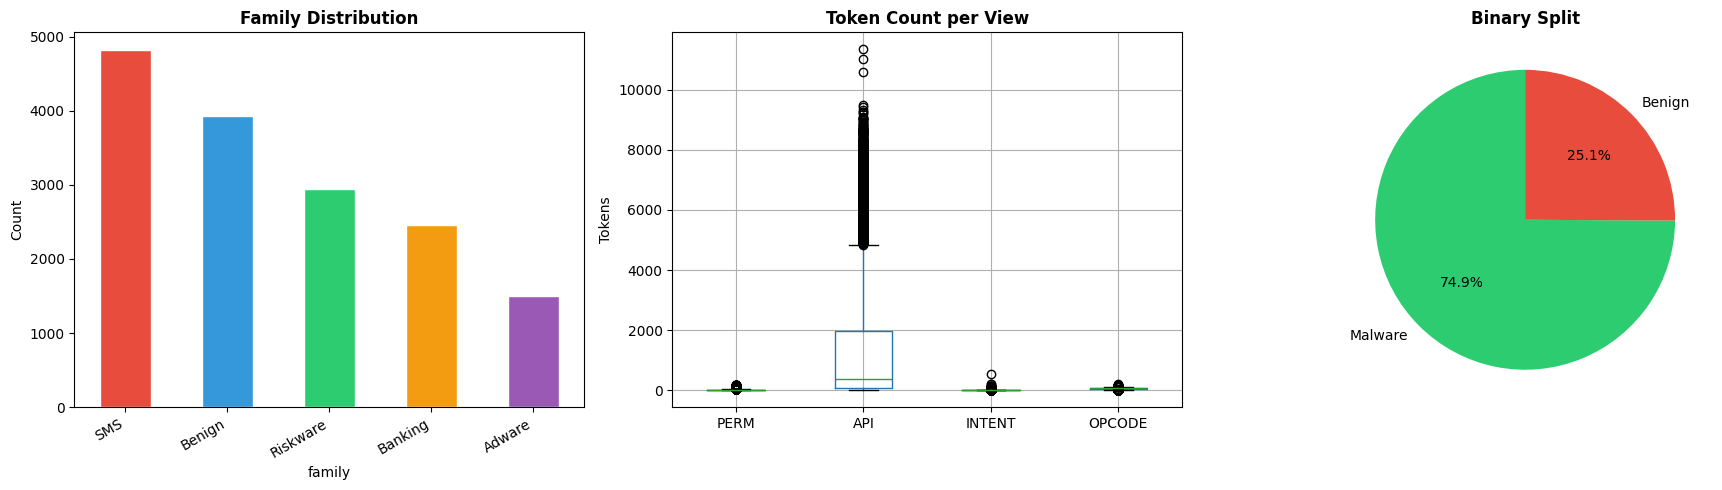

Plot saved: /content/drive/MyDrive/00-MalBert/00 Datasets/dataset_statistics.png


In [7]:
print("=" * 60)
print("DATASET VALIDATION")
print("=" * 60)

print(f"Shape: {df.shape}")

print(f"\nFamily distribution:")
for fam, cnt in df["family"].value_counts().items():
    pct = cnt / len(df) * 100
    print(f"  {fam:12s}: {cnt:5d} ({pct:5.1f}%)")

print(f"\nNull values: {df[["PERM","API","INTENT","OPCODE"]].isnull().sum().sum()}")
print(f"Duplicates: {df["file_name"].duplicated().sum()}")
fc = df["family"].value_counts()
print(f"Imbalance ratio: {fc.max()/fc.min():.2f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = ["#E74C3C", "#3498DB", "#2ECC71", "#F39C12", "#9B59B6"]
df["family"].value_counts().plot(kind="bar", ax=axes[0], color=colors, edgecolor="white")
axes[0].set_title("Family Distribution", fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha="right")

vl = pd.DataFrame({c: df[c].apply(lambda x: len(x.split()) if x.strip() else 0) for c in ["PERM","API","INTENT","OPCODE"]})
vl.boxplot(ax=axes[1])
axes[1].set_title("Token Count per View", fontweight="bold")
axes[1].set_ylabel("Tokens")

bc = df["family"].apply(lambda x: "Benign" if x=="Benign" else "Malware").value_counts()
bc.plot(kind="pie", ax=axes[2], autopct="%1.1f%%", colors=["#2ECC71","#E74C3C"], startangle=90)
axes[2].set_title("Binary Split", fontweight="bold")
axes[2].set_ylabel("")

plt.tight_layout()
plt.savefig(os.path.join(DATASET_DIR, "dataset_statistics.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Plot saved: {DATASET_DIR}/dataset_statistics.png")

## Cell 8: Save Final Dataset

Saves training-ready CSV with **4 separate view columns** for MalBERT-XAI.

In [8]:
print("=" * 60)
print("SAVING FINAL DATASET")
print("=" * 60)

final_cols = ["file_name", "family", "PERM", "API", "INTENT", "OPCODE"]
df_final = df[final_cols].copy()
df_final.to_csv(FINAL_OUTPUT_PATH, index=False)

size_mb = os.path.getsize(FINAL_OUTPUT_PATH) / (1024 * 1024)
print(f"\nSaved: {FINAL_OUTPUT_PATH}")
print(f"  Shape:    {df_final.shape}")
print(f"  Size:     {size_mb:.1f} MB")
print(f"  Families: {df_final["family"].unique().tolist()}")

# Metadata
meta_cols = [c for c in ["file_name","family","apk_size","permission_count","api_count","opcode_count","intent_count"] if c in df.columns]
if len(meta_cols) > 2:
    mp = FINAL_OUTPUT_PATH.replace(".csv", "_metadata.csv")
    df[meta_cols].to_csv(mp, index=False)
    print(f"  Metadata: {mp}")

# Verify
df_v = pd.read_csv(FINAL_OUTPUT_PATH, encoding="latin-1", on_bad_lines="skip", engine="python")
print(f"\nVerification: {df_v.shape[0]} rows loaded back")

# Sample
s = df_final.iloc[0]
print(f"\nSample:")
print(f"  family: {s["family"]}")
for v in ["PERM","API","INTENT","OPCODE"]:
    t = len(s[v].split()) if s[v].strip() else 0
    p = s[v][:60] + "..." if len(s[v]) > 60 else (s[v] if s[v] else "(empty)")
    print(f"  {v:7s}: [{t:4d} tokens] {p}")

print("\n" + "=" * 60)
print("PIPELINE COMPLETE!")
print("=" * 60)
print(f"\nNext: Set Config.DATASET_PATH = \"{FINAL_OUTPUT_PATH}\"")
print("The 4 view columns will be tokenized independently by MalBERT-XAI.")

SAVING FINAL DATASET

Saved: /content/drive/MyDrive/00-MalBert/00_final_dataset_multiview.csv
  Shape:    (15644, 6)
  Size:     291.3 MB
  Families: ['Adware', 'Banking', 'Benign', 'Riskware', 'SMS']
  Metadata: /content/drive/MyDrive/00-MalBert/00_final_dataset_multiview_metadata.csv

Verification: 15644 rows loaded back

Sample:
  family: Adware
  PERM   : [  12 tokens] ACCESS_COARSE_LOCATION ACCESS_FINE_LOCATION ACCESS_NETWORK_S...
  API    : [ 147 tokens] LoginIfNeed access$0 access$1 access$2 access$3 access$4 acc...
  INTENT : [   7 tokens] ACTION_BROADCAST_RECEIVER_WEIXIN CONNECTIVITY_CHANGE MAIN PA...
  OPCODE : [  70 tokens] invoke-virtual move-result-object const-string invoke-static...

PIPELINE COMPLETE!

Next: Set Config.DATASET_PATH = "/content/drive/MyDrive/00-MalBert/00_final_dataset_multiview.csv"
The 4 view columns will be tokenized independently by MalBERT-XAI.
